# GATA3 ChIP-seq track visualization

Plot the GATA3 ChIP-seq signal (bigwig) from ChIP Atlas (SRX092314, Th1 Cells, hg38)  
in a ±2 kb window around the TSS of IL13, TNF, PKM, MLLT3, and LTA.  
Gene coordinates from GENCODE v48 (hg38), same annotation as `process_chip_peaks.py`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import pyBigWig

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure matplotlib for Illustrator-compatible PDFs
mpl.rcParams['pdf.fonttype'] = 42  # Embed fonts as TrueType
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['figure.autolayout'] = True
plt.rcParams['figure.dpi'] = 300  # or 150, 200, etc.
plt.rcParams['savefig.dpi'] = 300

# Increase all font sizes
plt.rcParams['font.size'] = 16  # Base font size
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 15


In [2]:
CHIP_DIR = "/mnt/oak/users/emma/data/ChIP_atlas_data"
RESULTS_DIR = "/mnt/oak/users/emma/bin/GWT_perturbseq_analysis/src/9_ChIP_analysis/results"
BIGWIG = os.path.join(CHIP_DIR, "GATA3", "SRX092314.bw")
ANNOTATION_FILE = (
    "/mnt/oak/users/emma/bin/GWT_perturbseq_analysis"
    "/src/5_sgRNA_annotation/genome/gene_annotations_hg38.parquet"
)

os.makedirs(RESULTS_DIR, exist_ok=True)

assert os.path.exists(BIGWIG), f"BigWig not found: {BIGWIG}\nRun download_gata3_bigwig.sh first."

## Gene TSS coordinates from GENCODE v48 (hg38)

Same annotation file as `process_chip_peaks.py`.

In [24]:
imm_genes = pd.read_csv('../../metadata/immune_effector_genes.csv')
cytokines = imm_genes[imm_genes['Category'] == 'Cytokine']['gene_name'].tolist()

TARGET_GENES = ['IL13',
 'TNFSF10',
 'IL32',
 'IL5',
 'TGFB1',
 'IL10',
 'IL16',
 'VEGFB',
 'TNFSF14',
 'TNF',
 'LTA',
 'IL23A']
WINDOW = 2_000  # bp upstream/downstream of TSS

genes_ann = pd.read_parquet(ANNOTATION_FILE)
genes_ann = genes_ann[genes_ann["gene_name"].isin(TARGET_GENES)].drop_duplicates("gene_name")

# TSS: start for + strand, end for - strand (same logic as process_chip_peaks.py)
genes_ann["tss"] = np.where(genes_ann["strand"] == "+", genes_ann["start"], genes_ann["end"])

# Ensure GENES order matches TARGET_GENES
GENES = {
    g: {
        "chrom":  row["chrom"],
        "tss":    int(row["tss"]),
        "start":  int(row["start"]),
        "end":    int(row["end"]),
        "strand": row["strand"],
    }
    for g in TARGET_GENES
    for _, row in genes_ann[genes_ann["gene_name"] == g].iterrows()
}

for g in TARGET_GENES:
    info = GENES[g]
    print(f"{g:8s}  {info['chrom']:5s}  TSS={info['tss']:,}  strand={info['strand']}")

IL13      chr5   TSS=132,656,263  strand=+
TNFSF10   chr3   TSS=172,523,475  strand=-
IL32      chr16  TSS=3,065,297  strand=+
IL5       chr5   TSS=132,556,838  strand=-
TGFB1     chr19  TSS=41,353,922  strand=-
IL10      chr1   TSS=206,774,541  strand=-
IL16      chr15  TSS=81,159,575  strand=+
VEGFB     chr11  TSS=64,234,584  strand=+
TNFSF14   chr19  TSS=6,670,588  strand=-
TNF       chr6   TSS=31,575,565  strand=+
LTA       chr6   TSS=31,572,054  strand=+
IL23A     chr12  TSS=56,334,174  strand=+


In [19]:
# TARGET_GENES = ["IL13", "TNF", "PKM", "MLLT3", "LTA"]
# WINDOW = 2_000  # bp upstream/downstream of TSS

# genes_ann = pd.read_parquet(ANNOTATION_FILE)
# genes_ann = genes_ann[genes_ann["gene_name"].isin(TARGET_GENES)].drop_duplicates("gene_name")

# # TSS: start for + strand, end for - strand (same logic as process_chip_peaks.py)
# genes_ann["tss"] = np.where(genes_ann["strand"] == "+", genes_ann["start"], genes_ann["end"])

# GENES = {
#     row["gene_name"]: {
#         "chrom":  row["chrom"],
#         "tss":    int(row["tss"]),
#         "strand": row["strand"],
#     }
#     for _, row in genes_ann.iterrows()
# }

# for g, info in GENES.items():
#     print(f"{g:8s}  {info['chrom']:5s}  TSS={info['tss']:,}  strand={info['strand']}")

## Helper: fetch bigwig signal over a region

In [25]:
def fetch_signal(bw, chrom, start, end, bins=500):
    """Return (positions, values) arrays for a bigwig region, binned to `bins` windows."""
    vals = bw.stats(chrom, start, end, type="mean", nBins=bins)
    vals = np.array([v if v is not None else 0.0 for v in vals], dtype=float)
    pos = np.linspace(start, end, bins)
    return pos, vals

In [26]:
# Load GATA3 consensus peaks
CONSENSUS_BED = os.path.join(CHIP_DIR, "GATA3", "GATA3_consensus_peaks.bed")
consensus_peaks = pd.read_csv(
    CONSENSUS_BED, sep="\t", header=None,
    names=["chrom", "start", "end"],
    usecols=[0, 1, 2],
    dtype={"chrom": str, "start": int, "end": int},
)
print(f"Loaded {len(consensus_peaks):,} GATA3 consensus peaks")

Loaded 4,481 GATA3 consensus peaks


/tmp/ipykernel_3226796/143614435.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(out_pdf, bbox_inches="tight")
/tmp/ipykernel_3226796/143614435.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(out_png, bbox_inches="tight", dpi=150)
/home/emmadann/miniforge3/envs/rpy2-voodoo/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


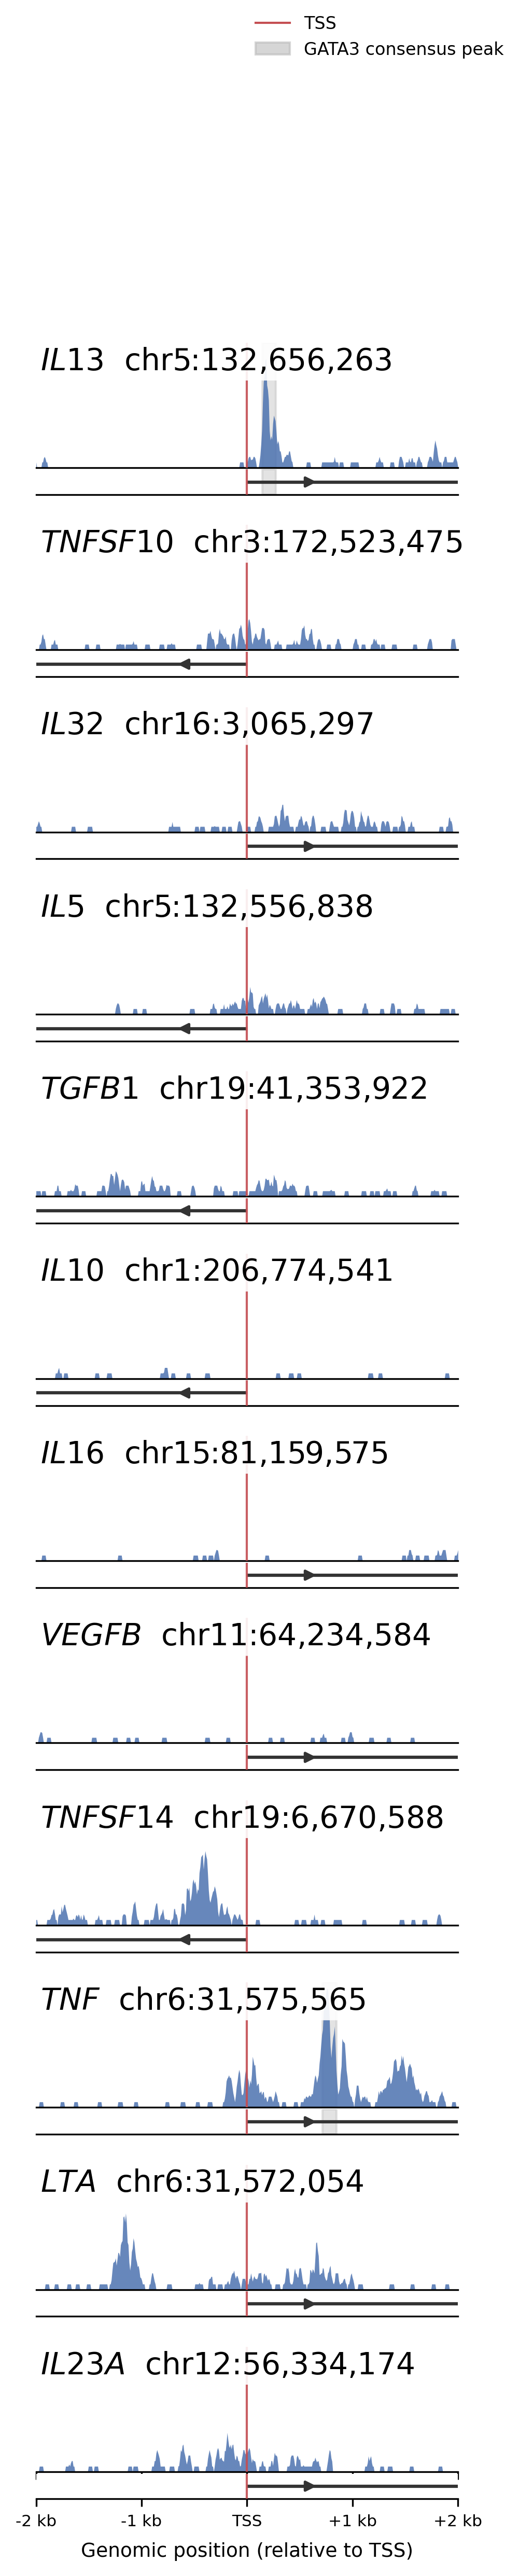

Saved: /mnt/oak/users/emma/bin/GWT_perturbseq_analysis/src/9_ChIP_analysis/results/gata3_track_tss_window.pdf


In [30]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.lines import Line2D

GENE_COLOR  = "#4C72B0"   # blue for signal fill
TSS_COLOR   = "#C44E52"   # red for TSS marker
ARROW_COLOR = "#333333"   # dark grey for gene body
PEAK_COLOR  = "#BBBBBB"   # light grey for consensus peak background

n_genes = len(GENES)

# --- Pre-fetch all signals to set a shared y-axis range ---
bw = pyBigWig.open(BIGWIG)
signals = {}
for gene, info in GENES.items():
    tss = info["tss"]
    pos, vals = fetch_signal(bw, info["chrom"], tss - WINDOW, tss + WINDOW)
    signals[gene] = (pos, vals)

ymax = max(v.max() for _, v in signals.values()) * 1.05

# --- Layout: outer GridSpec (one slot per gene), inner 2-row spec per gene ---
fig_height = 1.5 * n_genes
fig = plt.figure(figsize=(3.5, fig_height))
# Reduce white space between rows by lowering hspace from 0.45 to 0.20
outer_gs = GridSpec(n_genes, 1, figure=fig, hspace=0.20)

axes_signal = []
axes_gene   = []

for i, (gene, info) in enumerate(GENES.items()):
    chrom  = info["chrom"]
    tss    = info["tss"]
    gstart = info["start"]
    gend   = info["end"]
    strand = info["strand"]

    region_start = tss - WINDOW
    region_end   = tss + WINDOW
    is_last = i == n_genes - 1

    # Reduce inner row spacing from 0.06 to 0.025 for tighter packing
    inner_gs = GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer_gs[i],
        height_ratios=[5, 1], hspace=0.025,
    )
    ax_sig  = fig.add_subplot(inner_gs[0])
    ax_gene = fig.add_subplot(inner_gs[1], sharex=ax_sig)
    axes_signal.append(ax_sig)
    axes_gene.append(ax_gene)

    pos, vals = signals[gene]

    # --- Consensus peak background boxes ---
    overlapping = consensus_peaks[
        (consensus_peaks["chrom"] == chrom) &
        (consensus_peaks["start"] < region_end) &
        (consensus_peaks["end"]   > region_start)
    ]
    for _, pk in overlapping.iterrows():
        pk_start = max(pk["start"], region_start)
        pk_end   = min(pk["end"],   region_end)
        ax_sig.axvspan(pk_start, pk_end, color=PEAK_COLOR, alpha=0.4, zorder=0)
        ax_gene.axvspan(pk_start, pk_end, color=PEAK_COLOR, alpha=0.4, zorder=0)

    # --- Signal track ---
    ax_sig.fill_between(pos, vals, color=GENE_COLOR, alpha=0.85, linewidth=0, zorder=1)
    ax_sig.axvline(tss, color=TSS_COLOR, lw=1.0, ls="-", alpha=0.9, zorder=3)
    ax_sig.set_xlim(region_start, region_end)
    ax_sig.set_ylim(0, ymax)
    # Remove y-axis by hiding ticks, labels, and left spine
    ax_sig.set_yticks([])
    ax_sig.set_ylabel("")  # Remove label
    ax_sig.spines[["top", "right", "left"]].set_visible(False)
    plt.setp(ax_sig.get_yticklabels(), visible=False)
    plt.setp(ax_sig.get_xticklabels(), visible=False)

    # Gene name + locus in upper-left corner of signal plot with white background
    ax_sig.text(
        0.01, 0.97, f"$\\it{{{gene}}}$  {chrom}:{tss:,}",
        transform=ax_sig.transAxes,
        ha="left", va="top", fontsize=14,
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.15", alpha=0.9)
    )

    # --- Gene body track ---
    body_start = max(gstart, region_start)
    body_end   = min(gend,   region_end)

    ax_gene.hlines(0, body_start, body_end, color=ARROW_COLOR, lw=1.5, zorder=1)

    arrow_dx = WINDOW * 0.35 * (1 if strand == "+" else -1)
    ax_gene.annotate(
        "", xy=(tss + arrow_dx, 0), xytext=(tss, 0),
        arrowprops=dict(arrowstyle="-|>", color=ARROW_COLOR, lw=1.2,
                        mutation_scale=10),
        zorder=2,
    )

    ax_gene.axvline(tss, color=TSS_COLOR, lw=1.0, ls="-", alpha=0.9, zorder=3)
    ax_gene.set_xlim(region_start, region_end)
    ax_gene.set_ylim(-0.8, 0.8)
    ax_gene.set_yticks([])
    ax_gene.spines[["top", "right", "left"]].set_visible(False)

    if is_last:
        ticks  = [region_start, tss - 1000, tss, tss + 1000, region_end]
        labels = ["-2 kb", "-1 kb", "TSS", "+1 kb", "+2 kb"]
        ax_gene.set_xticks(ticks)
        ax_gene.set_xticklabels(labels, fontsize=7.5)
        ax_gene.set_xlabel("Genomic position (relative to TSS)", fontsize=9, labelpad=6)
    else:
        ax_gene.set_xticks([])

bw.close()

# Legend
peak_patch = mpatches.Patch(color=PEAK_COLOR, alpha=0.6, label="GATA3 consensus peak")
tss_line   = Line2D([0], [0], color=TSS_COLOR, lw=1.0, label="TSS")
fig.legend(handles=[tss_line, peak_patch], loc="upper right", fontsize=8, frameon=False)

out_pdf = os.path.join(RESULTS_DIR, "gata3_track_tss_window.pdf")
out_png = os.path.join(RESULTS_DIR, "gata3_track_tss_window.png")
plt.savefig(out_pdf, bbox_inches="tight")
plt.savefig(out_png, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved: {out_pdf}")

## Per-locus combined views

One plot per locus. TNF and LTA are grouped together (same chromosome, ~3.5 kb apart);  
all other genes get individual plots. Region = outermost TSS ± 2 kb.

In [14]:
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

LOCI = [
    ["IL13"],
    ["LTA", "TNF"],
    ["PKM"],
    ["MLLT3"],
]

FS_TICK  = 11
FS_LABEL = 13

n_loci = len(LOCI)

# --- Pre-fetch signals for all loci ---
bw = pyBigWig.open(BIGWIG)
locus_data = {}
for locus_genes in LOCI:
    key    = "_".join(locus_genes)
    chrom  = GENES[locus_genes[0]]["chrom"]
    tss_vals = [GENES[g]["tss"] for g in locus_genes]
    r_start  = min(tss_vals) - WINDOW
    r_end    = max(tss_vals) + WINDOW
    pos, vals = fetch_signal(bw, chrom, r_start, r_end, bins=800)
    locus_data[key] = dict(chrom=chrom, r_start=r_start, r_end=r_end,
                           pos=pos, vals=vals, genes=locus_genes)
bw.close()

# --- Figure ---
fig = plt.figure(figsize=(9, 3.2 * n_loci))
outer_gs = GridSpec(n_loci, 1, figure=fig, hspace=0.55)

for row_idx, locus_genes in enumerate(LOCI):
    key    = "_".join(locus_genes)
    d      = locus_data[key]
    chrom  = d["chrom"]
    r_start, r_end = d["r_start"], d["r_end"]
    pos, vals      = d["pos"], d["vals"]

    inner_gs = GridSpecFromSubplotSpec(
        2, 1, subplot_spec=outer_gs[row_idx],
        height_ratios=[5, 1], hspace=0.06,
    )
    ax_sig  = fig.add_subplot(inner_gs[0])
    ax_gene = fig.add_subplot(inner_gs[1], sharex=ax_sig)

    # Consensus peak background
    overlapping = consensus_peaks[
        (consensus_peaks["chrom"] == chrom) &
        (consensus_peaks["start"] < r_end) &
        (consensus_peaks["end"]   > r_start)
    ]
    for _, pk in overlapping.iterrows():
        pk_s = max(pk["start"], r_start)
        pk_e = min(pk["end"],   r_end)
        ax_sig.axvspan( pk_s, pk_e, color=PEAK_COLOR, alpha=0.4, zorder=0)
        ax_gene.axvspan(pk_s, pk_e, color=PEAK_COLOR, alpha=0.4, zorder=0)

    # Signal track
    ax_sig.fill_between(pos, vals, color=GENE_COLOR, alpha=0.85, linewidth=0, zorder=1)
    ax_sig.set_xlim(r_start, r_end)
    ax_sig.set_ylim(0, vals.max() * 1.08)
    ax_sig.spines[["top", "right"]].set_visible(False)
    ax_sig.tick_params(axis="y", labelsize=FS_TICK)
    plt.setp(ax_sig.get_xticklabels(), visible=False)

    # y-label on first row only
    if row_idx == 0:
        ax_sig.set_ylabel("ChIP-seq signal", fontsize=FS_LABEL)

    # Per-gene annotations
    for i, gene in enumerate(locus_genes):
        info   = GENES[gene]
        tss    = info["tss"]
        strand = info["strand"]

        ax_sig.axvline( tss, color=TSS_COLOR, lw=1.0, alpha=0.9, zorder=3)
        ax_gene.axvline(tss, color=TSS_COLOR, lw=1.0, alpha=0.9, zorder=3)

        # Gene body bar (clipped to window)
        body_s = max(info["start"], r_start)
        body_e = min(info["end"],   r_end)
        ax_gene.hlines(0, body_s, body_e, color=ARROW_COLOR, lw=1.8, zorder=1)

        # Direction arrow from TSS
        arrow_dx = WINDOW * 0.25 * (1 if strand == "+" else -1)
        ax_gene.annotate(
            "", xy=(tss + arrow_dx, 0), xytext=(tss, 0),
            arrowprops=dict(arrowstyle="-|>", color=ARROW_COLOR,
                            lw=1.3, mutation_scale=11),
            zorder=2,
        )

        # Gene name upstream of TSS, on the gene body line
        # "upstream" = left of TSS for + strand, right for - strand
        x_txt  = tss - WINDOW * 0.05 if strand == "+" else tss + WINDOW * 0.05
        ha_txt = "right" if strand == "+" else "left"
        ax_gene.text(
            x_txt, 0, f"$\\it{{{gene}}}$",
            ha=ha_txt, va="center", fontsize=FS_LABEL, color="black",
        )

    # Gene body axis formatting
    ax_gene.set_xlim(r_start, r_end)
    ax_gene.set_ylim(-1.0, 1.0)
    ax_gene.set_yticks([])
    ax_gene.spines[["top", "right", "left"]].set_visible(False)
    ax_gene.set_xlabel(f"{chrom} (bp)", fontsize=FS_LABEL)
    ax_gene.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax_gene.tick_params(axis="x", labelsize=FS_TICK, rotation=20)

# Single legend
peak_patch = mpatches.Patch(color=PEAK_COLOR, alpha=0.6, label="GATA3 consensus peak")
fig.legend(handles=[peak_patch], fontsize=FS_TICK, frameon=False,
           loc="upper right", bbox_to_anchor=(1.0, 1.0))

plt.suptitle("GATA3 ChIP-seq (SRX092314, Th1 Cells, hg38)", fontsize=15, y=1.01)

out_pdf = os.path.join(RESULTS_DIR, "gata3_track_all_loci.pdf")
out_png = os.path.join(RESULTS_DIR, "gata3_track_all_loci.png")
plt.savefig(out_pdf, bbox_inches="tight")
plt.savefig(out_png, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved: {out_pdf}")

KeyError: 'PKM'